In [70]:
import pymc as pm
import numpy as np
import nutpie
import pandas as pd
import seaborn as sns
import arviz as rv
from matplotlib import pyplot as plt
# Load the radon dataset
data = pd.read_csv(pm.get_data("radon.csv"))
data["log_radon"] = data["log_radon"].astype(np.float64)
county_idx, counties = pd.factorize(data.county)
coords = {"county": counties, "obs_id": np.arange(len(county_idx))}

# Create a simple hierarchical model for the radon dataset
with pm.Model(coords=coords, check_bounds=False) as pymc_model:
    intercept = pm.Normal("intercept", sigma=10)

    # County effects
    raw = pm.ZeroSumNormal("county_raw", dims="county")
    sd = pm.HalfStudentT("county_sd", 2, 10)
    county_effect = pm.Deterministic("county_effect", raw * sd, dims="county")

    # Global floor effect
    floor_effect = pm.Normal("floor_effect", sigma=2)

    # County:floor interaction
    raw = pm.ZeroSumNormal("county_floor_raw", dims="county")
    sd = pm.HalfNormal("county_floor_sd")
    county_floor_effect = pm.Deterministic("county_floor_effect", raw * sd, dims="county")
    mu = (
        intercept
        + county_effect[county_idx]
        + floor_effect * data.floor.values
        + county_floor_effect[county_idx] * data.floor.values
    )

    sigma = pm.HalfNormal("sigma", sigma=1.5)
    pm.Normal("log_radon", mu=mu, sigma=sigma, observed=data.log_radon.values, dims="obs_id")

In [71]:
compiled_model = nutpie.compile_pymc_model(pymc_model)

In [72]:
trace_pymc = nutpie.sample(compiled_model, draws=100_000)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,100300,0,0.41,15
,100300,0,0.37,15
,100300,0,0.40,15
,100300,0,0.39,15
,100300,0,0.40,15
,100300,0,0.38,15


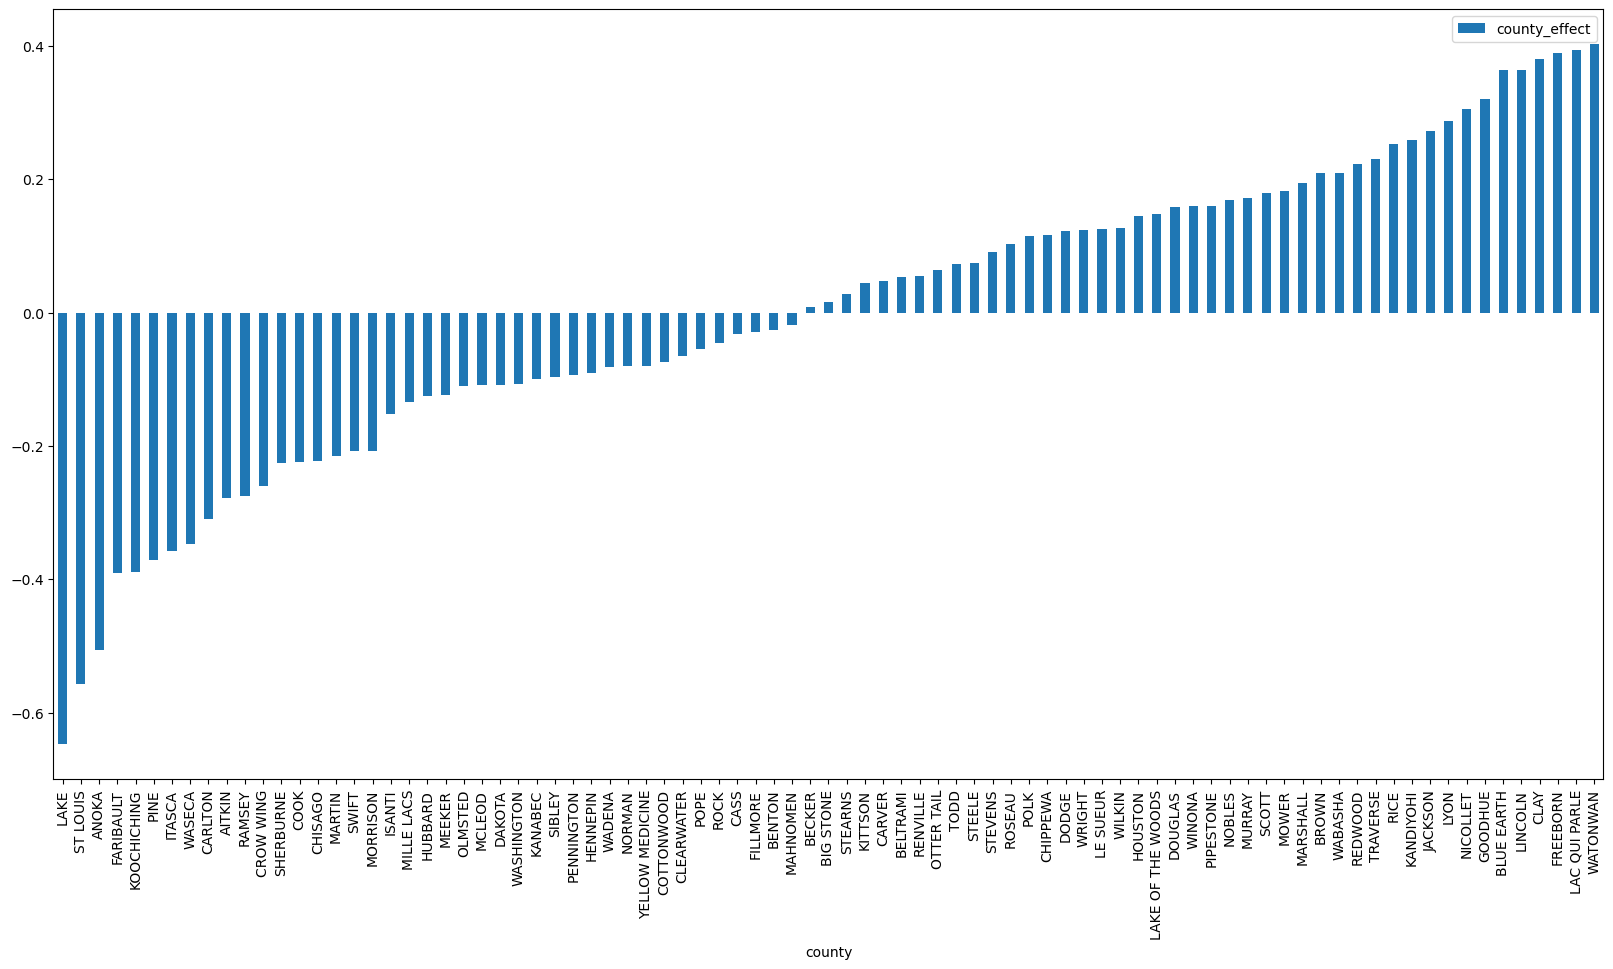

In [74]:
fig, ax = plt.subplots(figsize=(20, 10))
trace_pymc.posterior.county_effect.mean(dim=["draw", "chain"]).to_dataframe().sort_values("county_effect").plot.bar(ax=ax)
ax.tick_params(axis='x', labelrotation=90)

In [121]:
df = trace_pymc.posterior.county_effect.to_dataframe().unstack()
qs = df.quantile([0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).T.sort_values(0.5).loc["county_effect"]

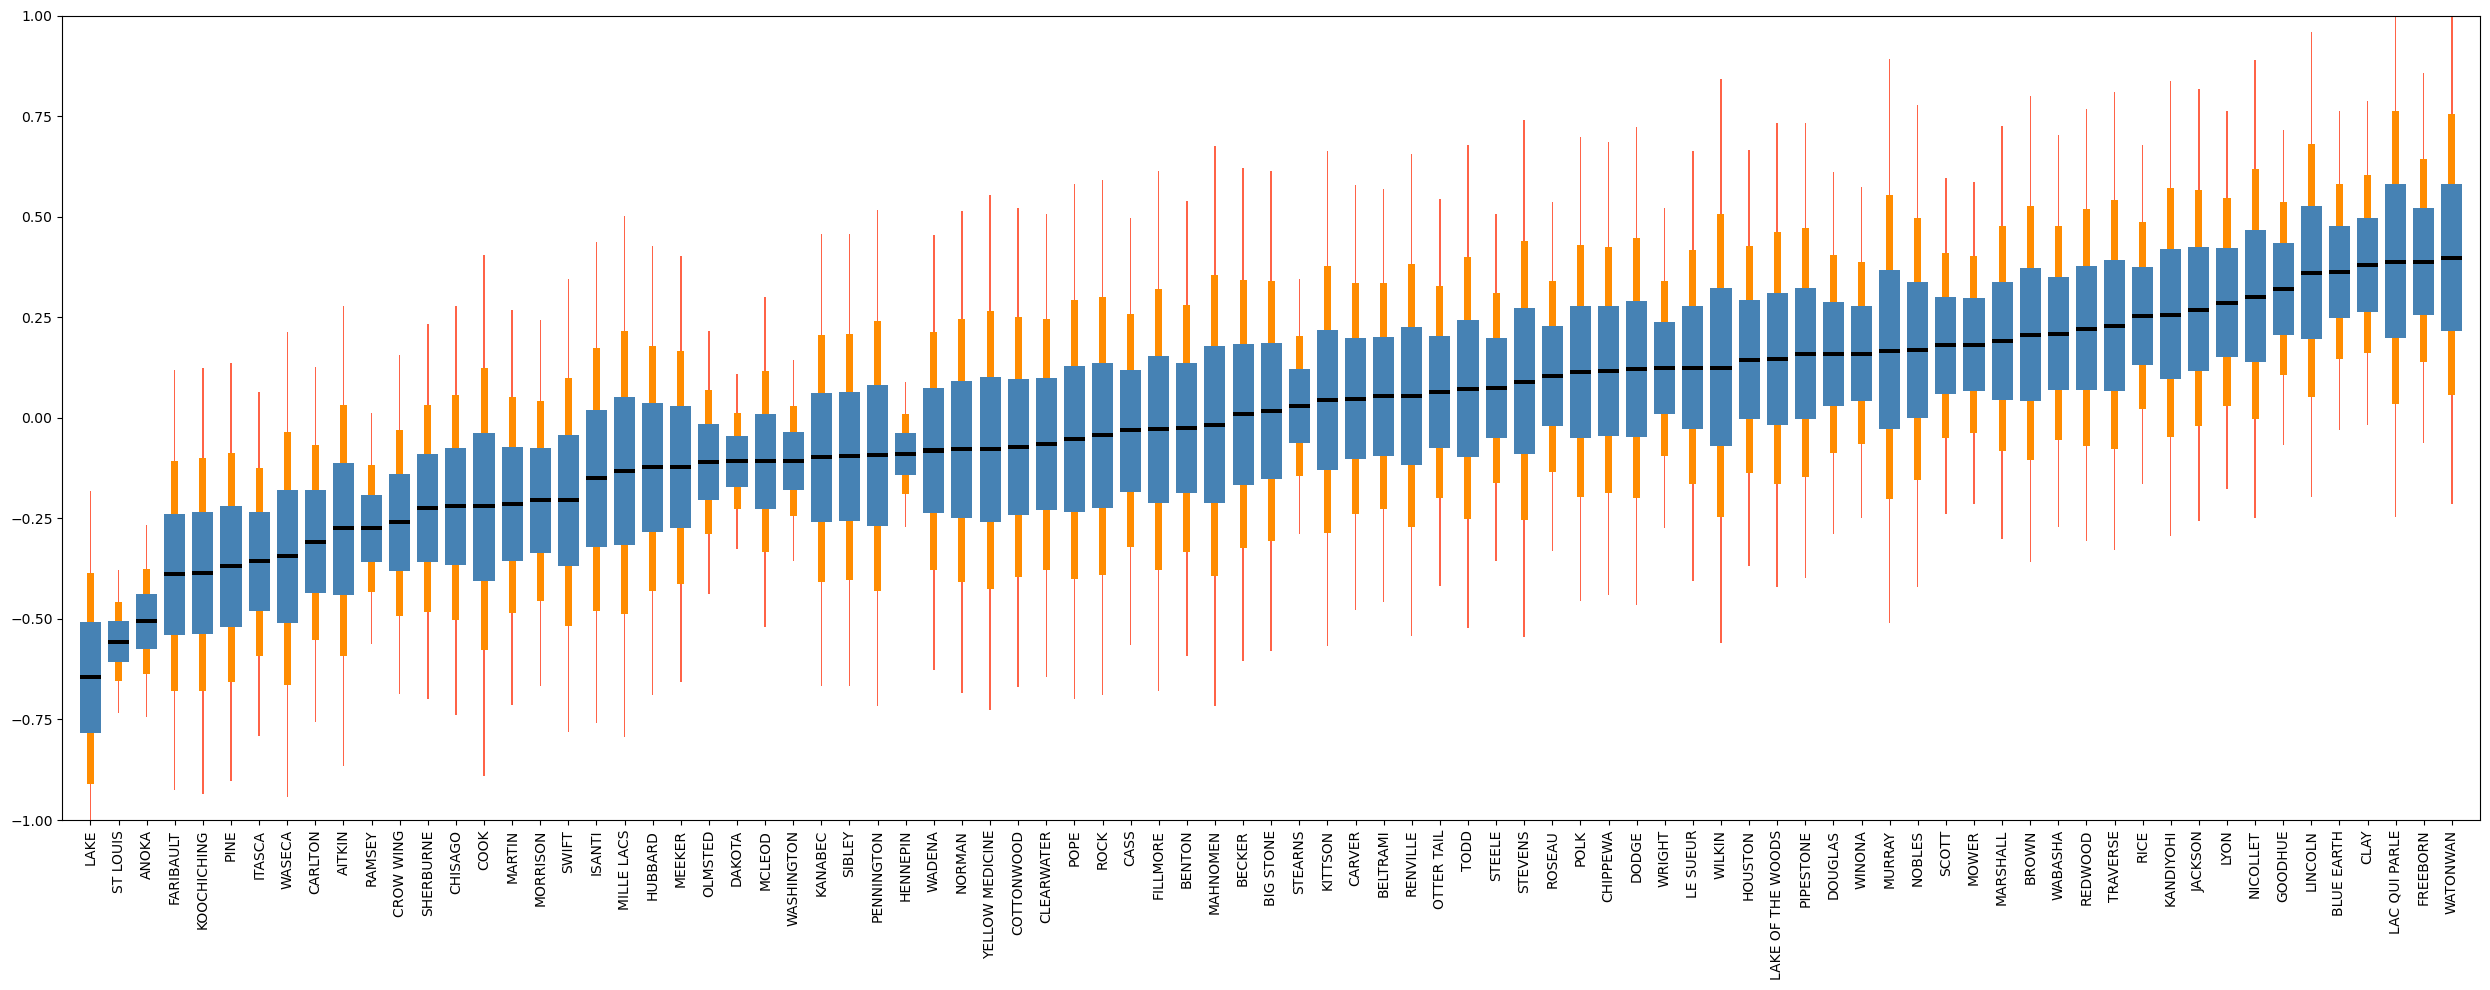

In [128]:
fig, ax = plt.subplots(figsize=(25, 10))
ax.bar(range(len(qs)), bottom=qs[0.01], height=qs[0.99]-qs[0.01], width=0.05, color="tomato")
ax.bar(range(len(qs)), bottom=qs[0.1], height=qs[0.9]-qs[0.1], width=0.25, color="darkorange")
ax.bar(range(len(qs)), bottom=qs[0.25], height=qs[0.75]-qs[0.25], width=0.75, color="steelblue")
ax.bar(range(len(qs)), bottom=qs[0.5]-0.005, height=0.01, width=0.75, color="black")
ax.set_xticks(range(len(qs)))
ax.set_xticklabels(qs.index)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-1, 1)
ax.set_xlim(-1, len(qs))
fig.tight_layout()

In [149]:
df = trace_pymc.posterior.county_floor_effect.to_dataframe().unstack()
qs = df.quantile([0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).T.sort_values(0.5).loc["county_floor_effect"]

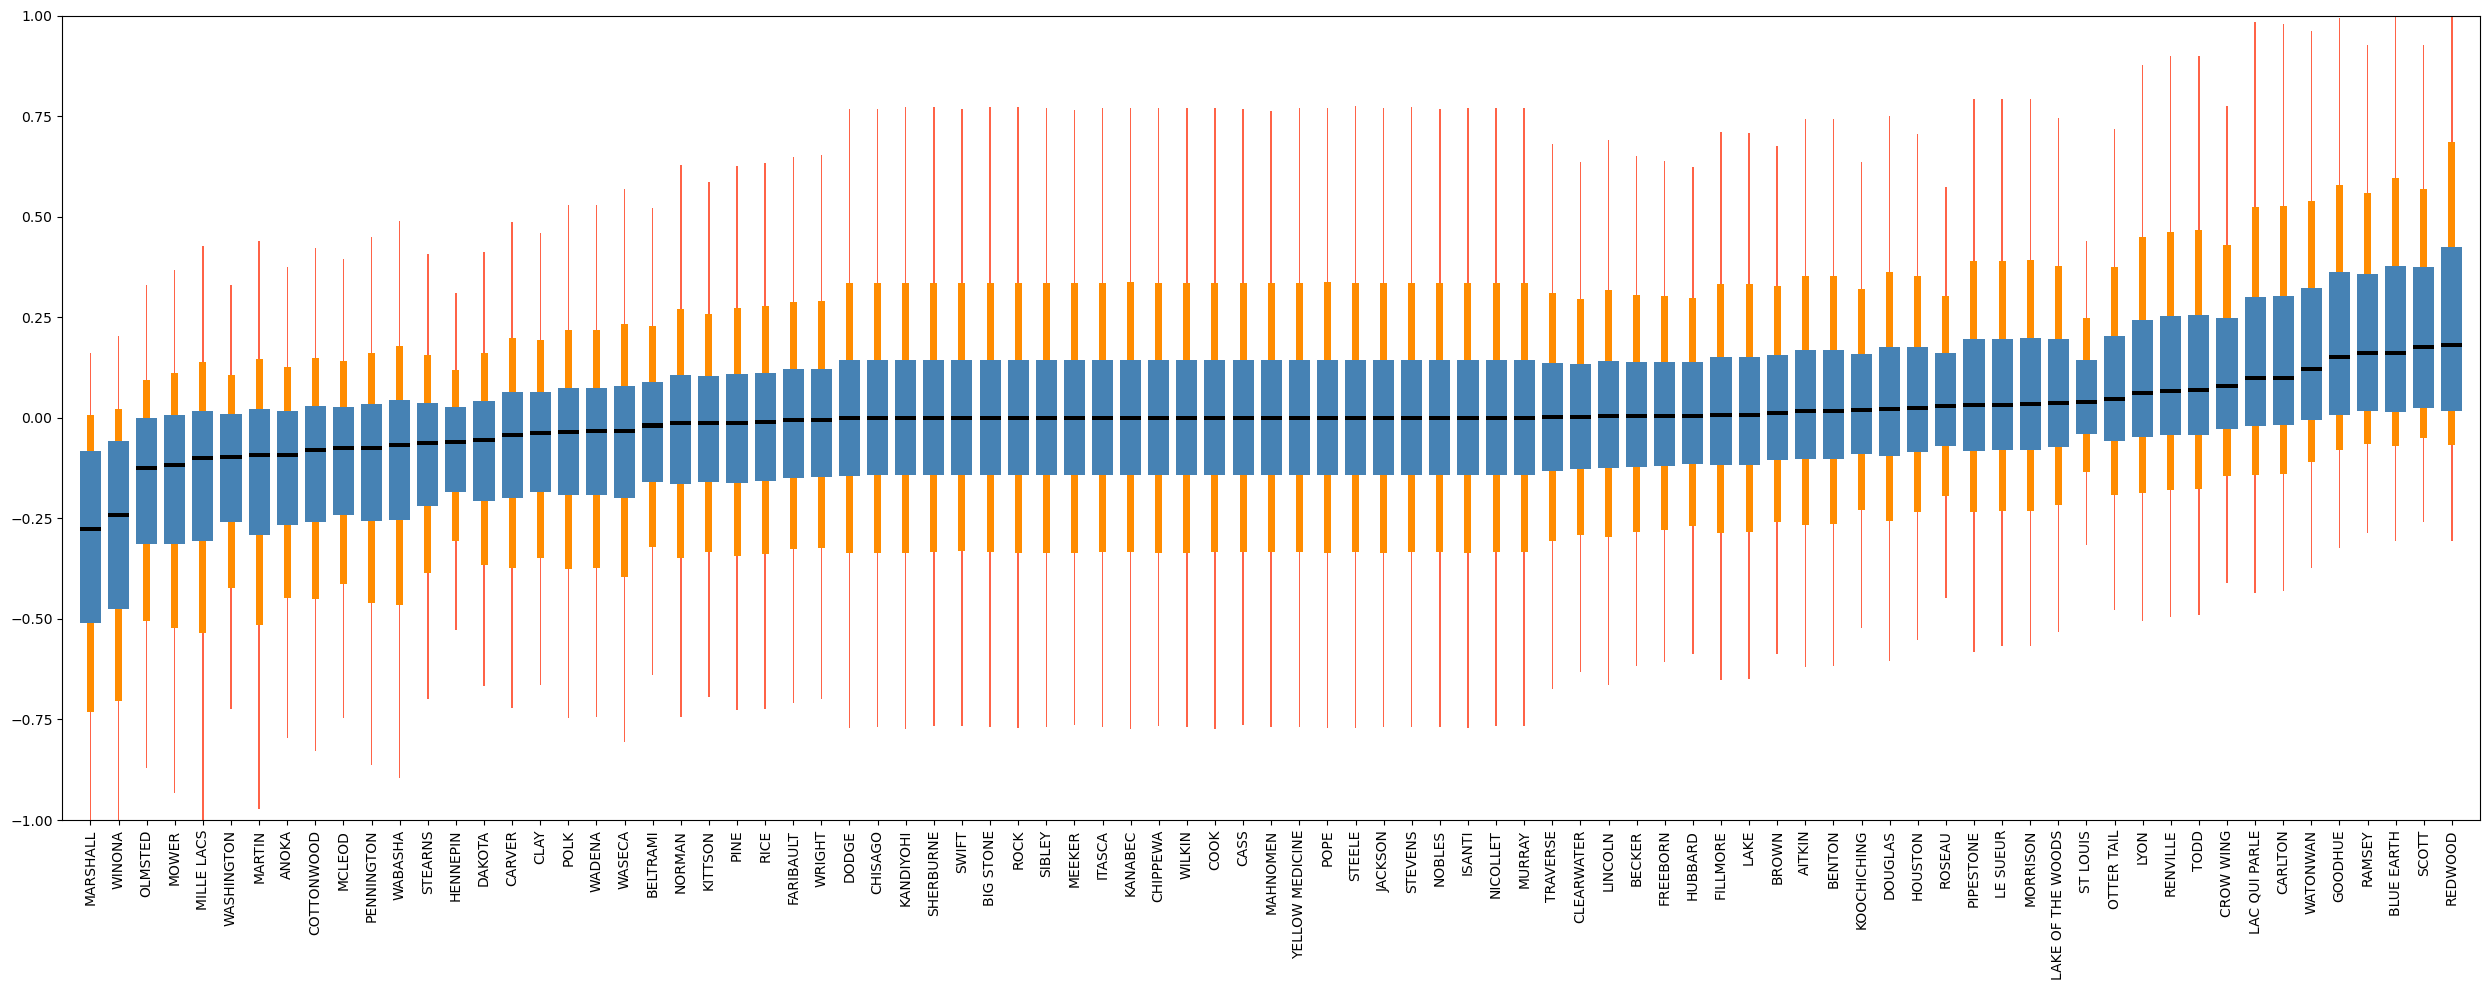

In [150]:
fig, ax = plt.subplots(figsize=(25, 10))
ax.bar(range(len(qs)), bottom=qs[0.01], height=qs[0.99]-qs[0.01], width=0.05, color="tomato")
ax.bar(range(len(qs)), bottom=qs[0.1], height=qs[0.9]-qs[0.1], width=0.25, color="darkorange")
ax.bar(range(len(qs)), bottom=qs[0.25], height=qs[0.75]-qs[0.25], width=0.75, color="steelblue")
ax.bar(range(len(qs)), bottom=qs[0.5]-0.005, height=0.01, width=0.75, color="black")
ax.set_xticks(range(len(qs)))
ax.set_xticklabels(qs.index)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-1, 1)
ax.set_xlim(-1, len(qs))
fig.tight_layout()